In [38]:
import numpy as np
import matplotlib.pyplot as plt

In [39]:
problem = "G01"

In [40]:
fopts = {"G01": -15, "G02": -0.0803553, "G03" : -0.990866, "G04": -30665.5, "G05" : 5126.4981,
         "G06": -6961.81381, "G07" : 24.3062091, "G08" : -0.011182, "G09": 680.6300573, "G10": 7049.330923,
         "G11" : 0.750455}

In [41]:
fopt = fopts [problem]  

In [42]:
path = r"results/without_plog"

In [43]:
rounding_path = path + "/rbf_rounding/"+problem+"/"+problem
cobyla_path = path + "/rbf_cobyla/"+problem+"/"+problem
mies_path = path + "/rbf_mies/"+problem+"/"+problem

In [44]:
def pad_array_with_zeros(arr, value = 0, target_length=200):
    current_length = len(arr)
    if current_length < 1:
        arr = np.zeros(target_length)
    elif current_length < target_length:
        padding_length = target_length - current_length
        
        padding = np.full((padding_length,) + arr.shape[1:], value)
        
        arr = np.concatenate((padding, arr), axis=0)
    
    return arr

In [45]:
data1 = np.loadtxt(rounding_path+ "_0")
data2 = np.loadtxt(rounding_path+ "_5")
data3 = np.loadtxt(rounding_path+"_10")
data4 = np.loadtxt(rounding_path+"_50")
data5 = np.loadtxt(rounding_path+"_100")

In [46]:
data1 = pad_array_with_zeros(data1)
data2 = pad_array_with_zeros(data2)
data3 = pad_array_with_zeros(data3)
data4 = pad_array_with_zeros(data4)
data5 = pad_array_with_zeros(data5)

In [47]:
data_round = np.vstack((data1, data2, data3, data4, data5))
avg_round = np.average(data_round, axis = 0)
std_round = np.std(avg_round)
mean_round = np.mean(avg_round)

In [48]:
data1 = np.loadtxt(cobyla_path+ "_0")
data2 = np.loadtxt(cobyla_path+ "_5")
data3 = np.loadtxt(cobyla_path+"_10")
data4 = np.loadtxt(cobyla_path+"_50")
data5 = np.loadtxt(cobyla_path+"_100")

In [49]:
data1 = pad_array_with_zeros(data1)
data2 = pad_array_with_zeros(data2)
data3 = pad_array_with_zeros(data3)
data4 = pad_array_with_zeros(data4)
data5 = pad_array_with_zeros(data5)

In [50]:
data_cobyla = np.vstack((data1, data2, data3, data4, data5))
avg_cobyla = np.average(data_cobyla, axis = 0)
std_cobyla = np.std(avg_cobyla)
mean_cobyla = np.mean(avg_cobyla)

In [51]:
data1 = np.loadtxt(mies_path+ "_0")
data2 = np.loadtxt(mies_path+ "_5")
data3 = np.loadtxt(mies_path+"_10")
data4 = np.loadtxt(mies_path+"_50")
data5 = np.loadtxt(mies_path+"_100")

C:\Users\sanja\AppData\Local\Temp\ipykernel_11016\4012355710.py:3: UserWarning: loadtxt: input contained no data: "results/without_plog/rbf_mies/G01/G01_10"
  data3 = np.loadtxt(mies_path+"_10")
C:\Users\sanja\AppData\Local\Temp\ipykernel_11016\4012355710.py:5: UserWarning: loadtxt: input contained no data: "results/without_plog/rbf_mies/G01/G01_100"
  data5 = np.loadtxt(mies_path+"_100")


In [52]:
data1 = pad_array_with_zeros(data1)
data2 = pad_array_with_zeros(data2)
data3 = pad_array_with_zeros(data3)
data4 = pad_array_with_zeros(data4)
data5 = pad_array_with_zeros(data5)

In [53]:
data_mies = np.vstack((data1, data2, data3, data4, data5))
avg_mies = np.average(data_mies, axis = 0)
mean_mies = np.mean(avg_mies, axis=0)
std_mies = np.std(avg_mies, axis=0)

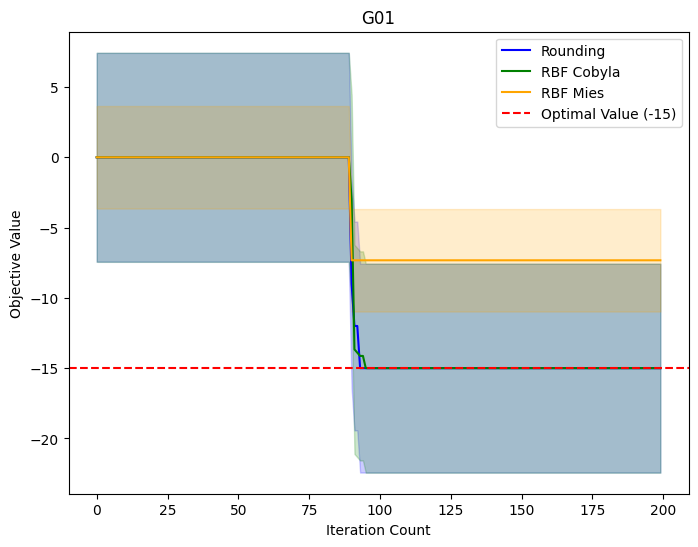

In [54]:
# Example data
# Assuming avg_round, avg_cobyla, avg_mies, std_round, std_cobyla, std_mies are arrays or lists of the same length
x = range(len(avg_round))  # x-axis values

plt.figure(figsize=(8, 6))

# Plot avg_round with shaded area representing standard deviation
plt.plot(avg_round, label='Rounding', color='blue')
plt.fill_between(x, np.array(avg_round) - np.array(std_round), np.array(avg_round) + np.array(std_round), color='blue', alpha=0.2)

# Plot avg_cobyla with shaded area representing standard deviation
plt.plot(avg_cobyla, label='RBF Cobyla', color='green')
plt.fill_between(x, np.array(avg_cobyla) - np.array(std_cobyla), np.array(avg_cobyla) + np.array(std_cobyla), color='green', alpha=0.2)

# Plot avg_mies with shaded area representing standard deviation
plt.plot(avg_mies, label='RBF Mies', color='orange')
plt.fill_between(x, np.array(avg_mies) - np.array(std_mies), np.array(avg_mies) + np.array(std_mies), color='orange', alpha=0.2)

plt.title(problem)
plt.xlabel('Iteration Count')
plt.ylabel('Objective Value')

plt.axhline(y=fopt, color='red', linestyle='--', label='Optimal Value ('+str(fopt)+')')
plt.legend()
plt.show()